# 1. Dutch names generation

Language model implemented with RNN

In [1]:
# %%bash
# gdown 1QDbtPWGQypYxiS4pC_hHBBtbRHk9gEtr
# unzip name_dataset.zip

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("name_dataset/data/NL.csv", header=None, dtype=pd.StringDtype()).dropna()
names_data = np.unique(df.loc[df[0].str.fullmatch("^[a-zA-Z]+$"), 0].to_numpy())

In [2]:
np.random.choice(names_data, 10)

array(['Oualim', 'Anys', 'Betishkor', 'Thygo', 'Classique', 'Babem',
       'Ilios', 'Arnoldwillem', 'Tpbm', 'Kot'], dtype=object)

In [3]:
len(names_data)

257736

## Dataset

**Processing pipeline:**

chars (tokens) $\to$ indices $\to$ embeddings $\to$ RNN output, hidden $\to$ next char logits

In [ ]:
from tokenizers import ByteLevelBPETokenizer

def train_bpe_tokenizer(names,
                        vocab_size: int = 1000,
                        min_frequency: int = 2):
    """
    Обучаем BPE на списке имён.
    """
    tokenizer = ByteLevelBPETokenizer()
    tokenizer.train_from_iterator(
        names,
        vocab_size=vocab_size,
        min_frequency=min_frequency,
        special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"],
    )
    return tokenizer

In [5]:
bpe_tokenizer = train_bpe_tokenizer(names_data, vocab_size=200, min_frequency=100)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output
from torch.utils.data import Dataset, DataLoader
import torch

class NamesDataset(Dataset):
    def __init__(self, names, bpe_tokenizer: ByteLevelBPETokenizer):
        self.names = names
        self.specials = ['<pad>', '<bos>', '<eos>']

        self.tokenizer = bpe_tokenizer

        self.pad_index = self.tokenizer.token_to_id('<pad>')
        self.bos_index = self.tokenizer.token_to_id('<bos>')
        self.eos_index = self.tokenizer.token_to_id('<eos>')

        self.max_len = max(len(self.encode(name)) for name in names)

    def __len__(self):
        return len(self.names)

    def str_to_idx(self, text: str):
        return self.tokenizer.encode(text).ids

    def idx_to_str(self, idx):
        if isinstance(idx, torch.Tensor):
            idx = idx.detach().cpu().tolist()
        return self.tokenizer.decode(idx)

    def encode(self, text: str):
        ids = self.tokenizer.encode(text).ids
        return [self.bos_index] + ids + [self.eos_index]

    def decode(self, idx):
        if isinstance(idx, torch.Tensor):
            idx = idx.detach().cpu().tolist()
        filtered = [
            i for i in idx
            if i not in (self.pad_index, self.bos_index, self.eos_index)
        ]
        return self.tokenizer.decode(filtered)

    def __getitem__(self, item):
        encoded = self.encode(self.names[item])
        padded = torch.full((self.max_len,), self.pad_index, dtype=torch.int64)
        padded[:len(encoded)] = torch.tensor(encoded, dtype=torch.int64)
        return padded, len(encoded)

In [7]:
dataset = NamesDataset(names_data, bpe_tokenizer)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [8]:
for names, _ in dataloader:
    break

# 0 - <pad> - paddint token
# 1 - <bos> - beginning of a sequence
# 2 - <eos> - end of a sequence
names[:4]

tensor([[ 1, 47, 92, 79, 72, 86,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 60, 82, 86, 75, 77, 68,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 40, 89, 76, 86, 79, 72,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 1, 42, 76, 85, 85,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
          0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0]])

## Generator model

Embedding + RNN + Linear head

In [9]:
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=2)

In [10]:
dataset.tokenizer.get_vocab_size()

260

In [ ]:
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.distributions.categorical import Categorical


class Generator(nn.Module):
    def __init__(self, dataset, embed_dim=32, hidden_dim=32, max_len=None):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=dataset.tokenizer.get_vocab_size(), embedding_dim=embed_dim,
                                      padding_idx=dataset.pad_index)
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, dataset.tokenizer.get_vocab_size())
        self.dataset = dataset
        self.max_len = dataset.max_len if max_len is None else max_len

    def forward(self, tokens, lengths):
        '''
        B - batch size
        L - sequence length
        E - embedding dim
        H - hidden dim
        V - vocab size
        '''
        # tokens: (B, L)
        embeds = self.embedding(tokens)
        outputs, hidden = self.rnn(embeds)
        logits = self.linear(outputs)
        # logits: (B, L, V)
        return logits

    @torch.no_grad()
    def inference(self, prefix=''):
        # encode prefix
        tokens = self.dataset.encode(prefix)[:-1]
        tokens = torch.tensor(tokens).unsqueeze(0).to(device)

        # generate hidden for prefix
        embeds = self.embedding(tokens)
        output, hidden = self.rnn(embeds)
        logits = self.linear(output)

        # sample new token from logits
        new_tokens = Categorical(logits=logits[:, -1:]).sample()
        tokens = torch.cat([tokens, new_tokens], dim=1)

        # 2 stopping conditions: reaching max len or getting <eos> token
        while tokens.shape[1] < self.max_len:
            if new_tokens.item() == self.dataset.eos_index:
                break

            # process newly obtained token
            embeds = self.embedding(new_tokens)
            output, hidden = self.rnn(embeds, hidden)
            logits = self.linear(output)
            # sample the next token from logits
            new_tokens = Categorical(logits=logits[:, -1:]).sample()
            tokens = torch.cat([tokens, new_tokens], dim=1)

        # decode result to a string
        return self.dataset.decode(tokens.squeeze())

In [12]:
model = Generator(dataset, embed_dim=32, hidden_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_index)

In [40]:
# inference for untrained model - trash
[model.inference('') for _ in range(10)]

["\nx���\x14ev����\t����̝'~�",
 '%Ͱ�^hM��8�8\x1f�]9Ii����sa�N�KL',
 'C���{�2\x12V:���(�\x13��L��\x16\x062��B�@�',
 '��\x0b��[U\x01\r�d\rQ@,��D�\x1bѹ���wH\x7f4/�',
 '�P��>���\t�&ú\x00r�7���-�Vh�YB��\x01]',
 '\x17JS�@�;�{��5K�\x0e�\\�?"\tD\x13�J��ƖT%',
 '=\x0b ��\x15x\x1d��(5��9Es�\x02<�ù�H���`�2',
 'EQ+�`g��|� /Ol�\x1c�d�Η̎D�\x17��B�',
 '��\x18���o�r�$Gb\x1cާ,�k�S�\x16���\x7f�>',
 '�>�(��P$�\x02Wt+\x07<�\x16>�����a%*8�\t��']

## Training

In [41]:
def plot_losses(losses):
    clear_output()
    plt.plot(range(1, len(losses) + 1), losses)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

In [42]:
from tqdm import trange

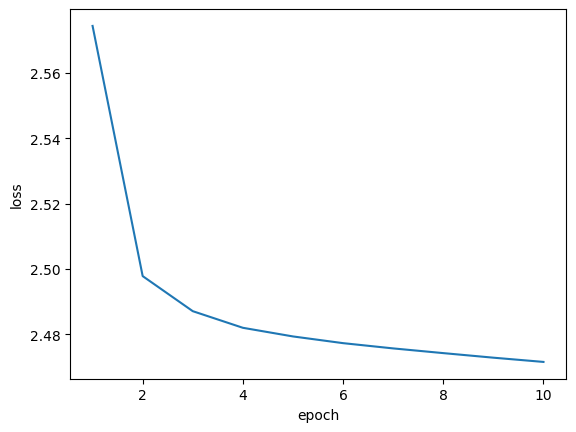

  5%|▌         | 10/200 [06:47<2:09:04, 40.76s/it]


KeyboardInterrupt: 

In [43]:
losses = []
num_epochs = 200

for epoch in trange(1, num_epochs + 1):
    running_loss = 0.0
    model.train()
    for tokens, lengths in dataloader:
        optimizer.zero_grad()
        tokens = tokens[:, :lengths.max()].to(device)
        logits = model(tokens[:, :-1], lengths - 1)
        # logits: (B, L, V), tokens: (B, L) - need to transpose logits
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * tokens.shape[0]
    
    losses += [running_loss / len(dataset)]
    
    if epoch % 10 == 0:
        plot_losses(losses)

In [93]:
# unconditional generation
[model.inference('') for _ in range(10)]

['Oomellesfon',
 'Sorvisa',
 'Erpalit',
 'Chactje',
 'Chane',
 'Ranjondelinca',
 'Isden',
 'Alempie',
 'Avants',
 'Pafika']

In [106]:
# conditional generation from prefix
[model.inference('Van') for _ in range(10)]

['Vanton',
 'Vanymikha',
 'Vanchalda',
 'Vanne',
 'Vanyun',
 'Vanca',
 'Vanayem',
 'Vannzlen',
 'Vanmisodil',
 'Vanwiny']

# 2. Image captioning

In [19]:
# %%bash
# kaggle datasets download -d hsankesara/flickr-image-dataset
# unzip flickr-image-dataset.zip

In [13]:
import os
import pandas as pd
from PIL import Image

In [14]:
captions = pd.read_csv('flickr30k_images/results.csv', sep='\|\ ').dropna()
captions

<>:1: SyntaxWarning: invalid escape sequence '\|'
<>:1: SyntaxWarning: invalid escape sequence '\|'
/var/tmp/ipykernel_1527904/311428869.py:1: SyntaxWarning: invalid escape sequence '\|'
  captions = pd.read_csv('flickr30k_images/results.csv', sep='\|\ ').dropna()
/var/tmp/ipykernel_1527904/311428869.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  captions = pd.read_csv('flickr30k_images/results.csv', sep='\|\ ').dropna()


,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
...,...,...,...
158910,998845445.jpg,0,A man in shorts and a Hawaiian shirt leans ove...
158911,998845445.jpg,1,"A young man hanging over the side of a boat , ..."
158912,998845445.jpg,2,A man is leaning off of the side of a blue and...
158913,998845445.jpg,3,"A man riding a small boat in a harbor , with f..."


1: A woman in a red shirt is speaking at a table in a room where three other people are listening to her .
2: A woman talks to two other women and a man with notepads in an office building with large windows .
3: People in a meeting setting paying attention to a speaker in an orange shirt .
4: A meeting of young people sitting at a conference table .
5: A classroom of students discussing lecture .


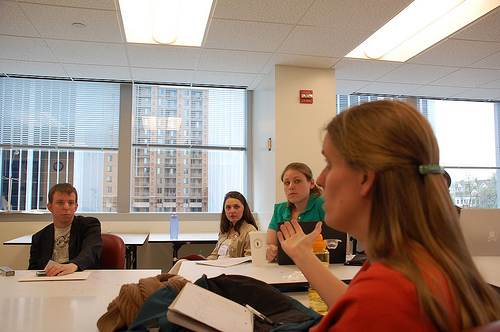

In [15]:
image_file = captions.image_name.sample(1).iloc[0]
for i, caption in enumerate(captions[captions.image_name == image_file].comment):
    print(f'{i + 1}:', caption)
Image.open(os.path.join('flickr30k_images/flickr30k_images', image_file))

In [16]:
image_ids = {k: i for i, k in enumerate(captions.image_name.unique())}
image_list = list(map(lambda x: x[0], sorted(image_ids.items(), key=lambda x: x[1])))
captions['image_id'] = captions.image_name.map(image_ids)

In [17]:
from torch.utils.data import Dataset, DataLoader

class ImagesDataset(Dataset):
    def __init__(self, root, image_list, transform=None):
        super().__init__()
        self.root = root
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, item):
        image_path = os.path.join(self.root, self.image_list[item])
        image = Image.open(image_path).convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image

In [18]:
import torch

device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=2)

In [19]:
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torch import nn

cnn_model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1).eval().to(device)
cnn_model.classifier = nn.Identity()

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/free001style/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 31.0MB/s]


In [20]:
import torchvision.transforms as T

transform = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.CenterCrop(224),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = ImagesDataset(root='flickr30k_images/flickr30k_images', image_list=image_list, transform=transform)
dataloader = DataLoader(dataset, num_workers=4, shuffle=False, batch_size=128)

In [21]:
from tqdm.auto import tqdm

image_embeds = []

with torch.no_grad():
    for images in tqdm(dataloader, total=len(dataloader)):
        embeds = cnn_model(images.to(device))
        image_embeds += [embeds.cpu()]

image_embeds = torch.cat(image_embeds, dim=0)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

  0%|          | 0/249 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

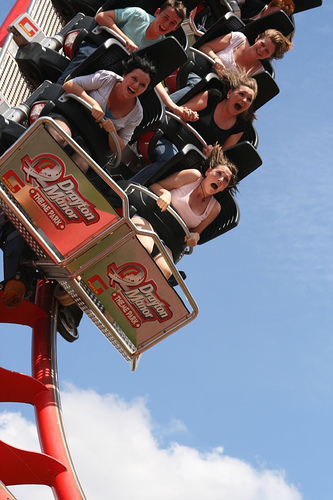

In [22]:
i = 1001
image = Image.open(f'flickr30k_images/flickr30k_images/{image_list[i]}').convert('RGB')
image

In [24]:
image_embeds[i]

tensor([1.5264, 1.4357, 0.1385,  ..., 0.7455, 0.2799, 0.5696])

In [25]:
cnn_model(transform(image).to(device).unsqueeze(0))

tensor([[1.5272, 1.4345, 0.1393,  ..., 0.7439, 0.2786, 0.5692]],
       device='cuda:2', grad_fn=<ViewBackward0>)

In [26]:
from sklearn.model_selection import train_test_split

train_images, test_images, train_embeds, test_embeds = \
    train_test_split(image_list, image_embeds, test_size=0.25, random_state=42)

train_embeds.shape, test_embeds.shape

(torch.Size([23837, 1280]), torch.Size([7946, 1280]))

In [ ]:
train_captions = captions[captions.image_name.isin(train_images)]
test_captions = captions[captions.image_name.isin(test_images)]

In [30]:
from nltk.tokenize import WordPunctTokenizer
from itertools import chain
from typing import Iterable, Union, Optional
from collections import Counter
import torch

tokenizer = WordPunctTokenizer()

class VocabPseudoVectorized:
    def __init__(self, train_data: Iterable[str],
                 unk_label: str = "<unk>",
                 bos_label: str = "<bos>",
                 eos_label: str = "<eos>",
                 pad_label: str = "<pad>",
                 unk_cutoff: int = 20):
        raw_counts = Counter(train_data)
        for token, frequency in tuple(raw_counts.items()):
            if frequency >= unk_cutoff:
                continue
            raw_counts.pop(token)
        remaining_tokens = list(raw_counts.keys())
        # add special tokens:
        remaining_tokens[0:0] = [pad_label, bos_label, eos_label, unk_label]

        self._token2idx = {
            token: id_ for id_, token in enumerate(remaining_tokens)
        }
        self._idx2token = {
            id_: token for id_, token in enumerate(remaining_tokens)
        }

    def _fetch_index(self, item: str):
        return self._token2idx.get(item, 0)

    def __getitem__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        if isinstance(item, Iterable) and not isinstance(item, str):
            return list(map(self.__getitem__, item))
    
        return self._fetch_index(item)

    def __call__(self, item: Union[str, Iterable[str]]) -> Union[int, list[int]]:
        return self[item]

    def __len__(self, ):
        return len(self._token2idx)

    def __contains__(self, item):
        return item in self._token2idx

    def lookup(self, item: Union[str, Iterable[str]]):
        result = []
        if isinstance(item, str):
            return self[item]
        for x in item:
            result.append(self.lookup(x))
        return result

    def get_itos(self, items: Optional[Iterable[str]]=None):
        if items is None:
            return self._idx2token
        if isinstance(items, torch.Tensor):
            items = items.detach().cpu().tolist()
        return [self._idx2token[i] for i in items]

In [31]:
train_captions['tokens'] = train_captions.comment.apply(tokenizer.tokenize)
test_captions['tokens'] = test_captions.comment.apply(tokenizer.tokenize)

/var/tmp/ipykernel_1527904/438791189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_captions['tokens'] = train_captions.comment.apply(tokenizer.tokenize)
/var/tmp/ipykernel_1527904/438791189.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_captions['tokens'] = test_captions.comment.apply(tokenizer.tokenize)


In [36]:
vocab = VocabPseudoVectorized(chain.from_iterable(train_captions.tokens))
itos = vocab._idx2token

PAD_IDX, BOS_IDX, EOS_IDX, UNK_IDX = vocab['<pad>'], vocab['<bos>'], vocab['<eos>'], vocab['<unk>']
VOCAB_SIZE = len(vocab)
VOCAB_SIZE

3235

In [46]:
MAX_LENGTH = 40

class CaptionsDataset(Dataset):
    def __init__(self, tokens, embeds):
        super().__init__()
        self.tokens = tokens
        self.embeds = embeds

    def __len__(self):
        return len(self.tokens)

    def tokens_to_idx(self, tokens):
        return [vocab[token] for token in tokens]
    
    def idx_to_tokens(self, idx):
        return [itos[index.item()] for index in idx]

    def encode(self, tokens):
        tokens = ['<bos>'] + tokens + ['<eos>']
        return self.tokens_to_idx(tokens)

    def decode(self, idx):
        tokens = self.idx_to_tokens(idx)
        return ' '.join(token for token in tokens if token not in ['<pad>', '<bos>', '<eos>', '<unk>'])

    def __getitem__(self, item):
        tokens = self.tokens.iloc[item].tokens
        encoded = self.encode(tokens)[:MAX_LENGTH + 2]
        padded = torch.full((MAX_LENGTH + 2, ), PAD_IDX, dtype=torch.int64)
        padded[:len(encoded)] = torch.tensor(encoded)

        image_id = self.tokens.iloc[item].image_id
        return padded, len(encoded), self.embeds[image_id]

In [47]:
train_set = CaptionsDataset(train_captions, image_embeds)
test_set = CaptionsDataset(test_captions, image_embeds)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
embeds_loader = DataLoader(test_embeds, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

In [48]:
captions_list = []

for image in tqdm(test_images):
    data = test_captions[test_captions.image_name == image]
    captions_list += [data.comment.str.lower().tolist()]

  0%|          | 0/7946 [00:00<?, ?it/s]

In [ ]:
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.distributions.categorical import Categorical
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights


class CaptionRNN(nn.Module):
    def __init__(self, image_embed_dim, embed_dim=256, hidden_dim=256, lstm_layers=1, dropout=0.1):
        super().__init__()
        self.lstm_layers = lstm_layers
        self.hidden_dim = hidden_dim

        self.image_embed_to_h0 = nn.Sequential(
            nn.Linear(image_embed_dim, lstm_layers * hidden_dim),
            nn.LeakyReLU(0.1),
        )
        self.image_embed_to_c0 = nn.Sequential(
            nn.Linear(image_embed_dim, lstm_layers * hidden_dim),
            nn.LeakyReLU(0.1),
        )

        self.embedding = nn.Embedding(num_embeddings=VOCAB_SIZE, embedding_dim=embed_dim,
                                      padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                            num_layers=lstm_layers, batch_first=True)
        self.linear = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, VOCAB_SIZE)
        )

    def forward(self, tokens, lengths, image_embeds):
        '''
        B - batch size
        M - lstm layers
        L - sequence length
        I - image embedding dim
        E - embedding dim
        H - hidden dim
        V - vocab size
        '''
        # image_embeds: (B, I)
        B = image_embeds.shape[0]
        h0 = self.image_embed_to_h0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        c0 = self.image_embed_to_c0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        # h0, co: (M, B, H)

        # tokens: (B, L)
        embeds = self.embedding(tokens)
        # embeds: (B, L, E) in padded form

        outputs, (h, c) = self.lstm(embeds, (h0, c0))
        logits = self.linear(outputs)
        # logits: (B, L, V)
        return logits

    @torch.no_grad()
    def inference(self, image_embeds):
        self.eval()
        # generate lstm input
        B = image_embeds.shape[0]
        h = self.image_embed_to_h0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        c = self.image_embed_to_c0(image_embeds).reshape(B, self.lstm_layers, self.hidden_dim).transpose(0, 1)
        h, c = h.contiguous(), c.contiguous()

        # init tokens with <bos>
        tokens = torch.full((B, 1), BOS_IDX, device=image_embeds.device)
        new_tokens = tokens

        # 2 stopping conditions: reaching max len or getting <eos> token
        while tokens.shape[1] < MAX_LENGTH:
            if ((tokens == EOS_IDX).sum(1) > 0).all():
                break

            # process newly obtained token
            embeds = self.embedding(new_tokens)
            output, (h, c) = self.lstm(embeds, (h, c))
            logits = self.linear(output)

            # get new tokens from logits
            new_tokens = logits.argmax(dim=-1)
            tokens = torch.cat([tokens, new_tokens], dim=1)

        return tokens

In [50]:
# testing
model = CaptionRNN(image_embeds.shape[1])

for tokens, lengths, embeds in train_loader:
    break

tokens = tokens[:, :lengths.max()]
logits = model(tokens, lengths, embeds)
assert logits.shape == (tokens.shape[0], tokens.shape[1], VOCAB_SIZE)

tokens = model.inference(embeds)
train_set.decode(tokens[0])

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

'Five high red caution bandanna stool letters smiles shot amusement star getting wrestling jog victory figures few pick pickup walks trains mountains letters transportation crayons camera rugby direction calm you tossing carefully customer sailboat opening stage may woven trip'

In [51]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import numpy as np


BLEU_FREQ = 5


def plot_losses(train_losses, test_losses, test_blues):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train', color='deepskyblue', linewidth=2)
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test', color='springgreen', linewidth=2)
    axs[0].set_ylabel('loss')

    axs[1].plot(BLEU_FREQ * np.arange(1, len(test_blues) + 1), test_blues, label='test',
                color='springgreen', linewidth=2)
    axs[1].set_ylabel('BLEU')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [52]:
from torchmetrics import BLEUScore


def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss = 0.0
    model.train()
    for tokens, lengths, embeds in tqdm(train_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        tokens = tokens[:, :lengths.max()].to(device)

        optimizer.zero_grad()
        logits = model(tokens[:, :-1], lengths - 1, embeds)
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * embeds.shape[0]

    train_loss /= len(train_loader.dataset)
    return train_loss


@torch.no_grad()
def validation_epoch(model, criterion, valid_loader, tqdm_desc):
    valid_loss = 0.0
    model.eval()
    for tokens, lengths, embeds in tqdm(valid_loader, desc=tqdm_desc):
        embeds = embeds.to(device)
        tokens = tokens[:, :lengths.max()].to(device)

        logits = model(tokens[:, :-1], lengths - 1, embeds)
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])

        valid_loss += loss.item() * embeds.shape[0]

    valid_loss /= len(valid_loader.dataset)
    return valid_loss


def evaluate_bleu(model, embeds_loader, captions):
    bleu = BLEUScore()
    predictions = []
    model.eval()
    for embeds in tqdm(embeds_loader, desc='Evaluating BLEU'):
        tokens = model.inference(embeds.to(device)).cpu()
        for token_list in tokens:
            predictions += [train_set.decode(token_list)]
    
    return bleu(predictions, captions).item()


def train(model, optimizer, scheduler, criterion, train_loader, valid_loader,
          embeds_loader, captions_list, num_epochs):
    train_losses, valid_losses, valid_blues = [], [], []

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        valid_loss = validation_epoch(
            model, criterion, valid_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if epoch % BLEU_FREQ == 0:
            valid_bleu = evaluate_bleu(model, embeds_loader, captions_list)
            valid_blues += [valid_bleu]

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        valid_losses += [valid_loss]
        plot_losses(train_losses, valid_losses, valid_blues)

In [53]:
NUM_EPOCHS = 20

model = CaptionRNN(image_embeds.shape[1], dropout=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = None
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

sum(param.numel() for param in model.parameters())

2841763

In [54]:
print(f'Random BLEU: {evaluate_bleu(model, embeds_loader, captions_list):.4f}')

/home/free001style/miniconda3/envs/wan/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `BLEUScore` from `torchmetrics` was deprecated and will be removed in 2.0. Import `BLEUScore` from `torchmetrics.text` instead.
  _future_warning(


Evaluating BLEU:   0%|          | 0/63 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Random BLEU: 0.0000


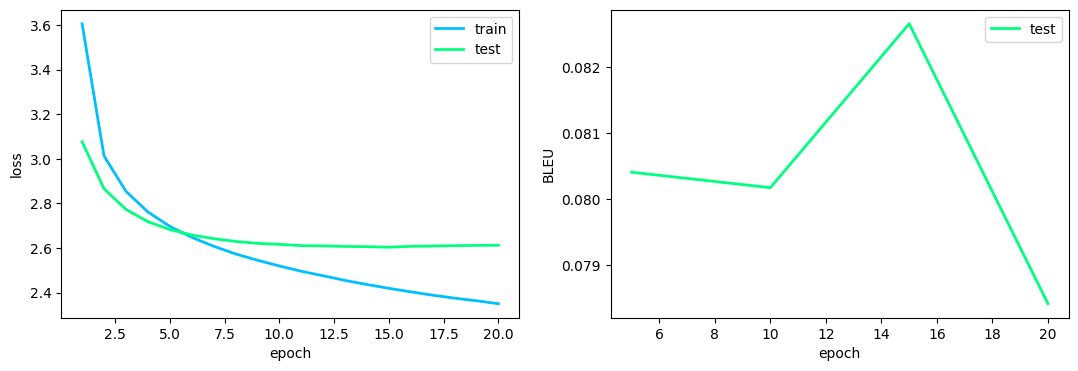

In [55]:
train(model, optimizer, scheduler, criterion, train_loader, test_loader,
      embeds_loader, captions_list, NUM_EPOCHS)

In [56]:
def caption_random_test_image():
    index = np.random.randint(len(test_images))
    image_file = test_images[index]
    tokens = model.inference(test_embeds[index].unsqueeze(0).to(device)).cpu().squeeze()
    prediction = train_set.decode(tokens)
    print('Prediction:', prediction)

    for i, caption in enumerate(captions[captions.image_name == image_file].comment):
        print(f'GT caption #{i + 1}:', caption)

    return Image.open(os.path.join('flickr30k_images/flickr30k_images', image_file)).convert('RGB')

Prediction: A group of people are standing in a body of water .
GT caption #1: A group of girls walking and talking along the beach with a building in the background .
GT caption #2: women on the beach returning to their car after long day
GT caption #3: Five women walk along a beach wearing flip-flops .
GT caption #4: A group of women walking away from a beach .
GT caption #5: Young women coming home from the beach .


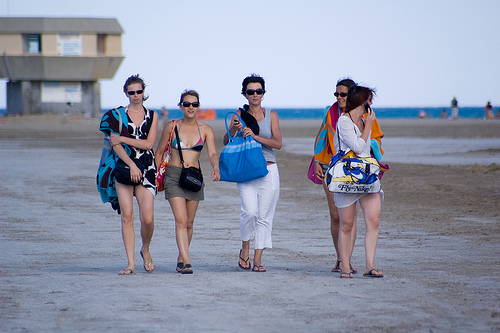

In [57]:
caption_random_test_image()

Prediction: A man in a blue shirt and jeans is walking down a sidewalk .
GT caption #1: A cleaning lady walks down the road with a sweeping machine what looks to be an entry way of a building .
GT caption #2: A woman pushes a cleaning machine while walking on a brick pathway beside a minivan yellow cab .
GT caption #3: A woman pushing a piece of cleaning equipment , while walking in front of a cab .
GT caption #4: A woman wearing a white shirt walks on the sidewalk with a large sweeper .
GT caption #5: Person in white shirt standing outside with a buffer machine .


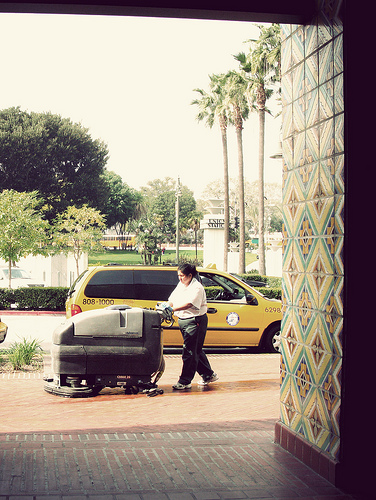

In [58]:
caption_random_test_image()

Prediction: A woman in a black shirt and jeans is sitting on a bench .
GT caption #1: A man with dark glasses , a black jacket , and a white and red horizontally-striped shirt pointing at something while standing on a sidewalk .
GT caption #2: A man in sunglasses , a red striped sweater , and a leather jacket smiles and points his finger .
GT caption #3: A man in a leather jacket and striped shirt points at something off-camera .
GT caption #4: A man with shaggy hair and a moustache pointing down a street .
GT caption #5: The man with the red and gray shirt and glasses is pointing .


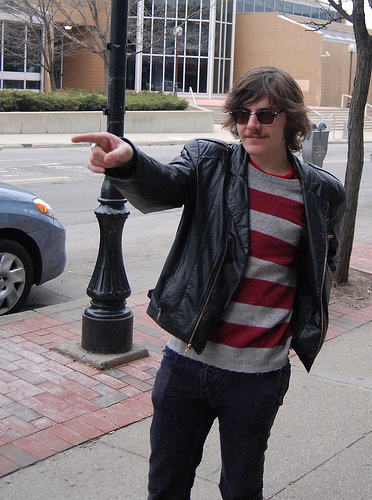

In [59]:
caption_random_test_image()

Prediction: A young boy is playing with a toy gun .
GT caption #1: A young boy with a white shirt is holding two large ripe green organic food items .
GT caption #2: A boy in a gray t-shirt , brown hair , holding two large cucumbers .
GT caption #3: A young boy in a gray shirt holds onto two over-sized cucumbers .
GT caption #4: A boy in a gray shirt holding two over-sized cucumbers .
GT caption #5: A boy carrying two green vegetables .


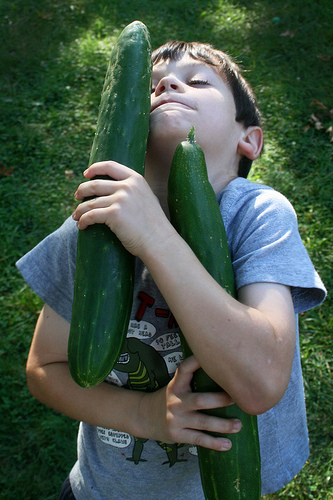

In [60]:
caption_random_test_image()

# 3. Code reproducibility

In [29]:
import torch
import numpy as np
import random
import os
from torch import nn

def set_random_seed(seed):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' # or :16:8

In [30]:
set_random_seed(0xDEADF00D)

In [31]:
a = nn.Conv2d(1, 1, kernel_size=3, bias=True).to("cuda:2")
a.weight, a.bias

(Parameter containing:
 tensor([[[[-0.2808, -0.1553,  0.2176],
           [ 0.1008,  0.0012, -0.1642],
           [-0.0923, -0.2754,  0.3187]]]], device='cuda:2', requires_grad=True),
 Parameter containing:
 tensor([0.2705], device='cuda:2', requires_grad=True))

In [32]:
x = torch.randn(1, 1, 5, 5).to("cuda:2")
x

tensor([[[[-0.4343,  1.8815,  0.1638,  1.3481, -0.4343],
          [ 0.1004, -0.4767, -0.0350,  2.4472,  2.7177],
          [ 2.8190, -0.1433, -0.3422, -0.1957,  0.0862],
          [-1.5015,  1.1933,  0.6985, -0.4518,  0.6744],
          [-1.0870, -1.9972,  0.7447,  0.6049,  2.6260]]]], device='cuda:2')

In [33]:
a(x)

tensor([[[[-0.1785, -0.3950, -0.4133],
          [ 0.6813,  0.5130,  0.7175],
          [ 0.0497,  0.6885,  0.9763]]]], device='cuda:2',
       grad_fn=<ConvolutionBackward0>)

In [34]:
from torch.utils.data import DataLoader
dataloader = DataLoader(torch.arange(20), shuffle=True, num_workers=4, batch_size=3)
for batch in dataloader:
    print(batch)

tensor([5, 4, 8])
tensor([17,  7,  0])
tensor([ 1, 10, 15])
tensor([ 6,  3, 12])
tensor([ 2, 11, 14])
tensor([18, 13, 16])
tensor([ 9, 19])


In [35]:
set_random_seed(0xDEADF00D)

In [ ]:
a = nn.Conv2d(1, 1, kernel_size=3, bias=True).to("cuda:2")
a.weight, a.bias

(Parameter containing:
 tensor([[[[-0.2808, -0.1553,  0.2176],
           [ 0.1008,  0.0012, -0.1642],
           [-0.0923, -0.2754,  0.3187]]]], device='cuda:2', requires_grad=True),
 Parameter containing:
 tensor([0.2705], device='cuda:2', requires_grad=True))

In [37]:
x = torch.randn(1, 1, 5, 5).to("cuda:2")
x

tensor([[[[-0.4343,  1.8815,  0.1638,  1.3481, -0.4343],
          [ 0.1004, -0.4767, -0.0350,  2.4472,  2.7177],
          [ 2.8190, -0.1433, -0.3422, -0.1957,  0.0862],
          [-1.5015,  1.1933,  0.6985, -0.4518,  0.6744],
          [-1.0870, -1.9972,  0.7447,  0.6049,  2.6260]]]], device='cuda:2')

In [38]:
a(x)

tensor([[[[-0.1785, -0.3950, -0.4133],
          [ 0.6813,  0.5130,  0.7175],
          [ 0.0497,  0.6885,  0.9763]]]], device='cuda:2',
       grad_fn=<ConvolutionBackward0>)

In [39]:
dataloader = DataLoader(torch.arange(20), shuffle=True, num_workers=4, batch_size=3)
for batch in dataloader:
    print(batch)

tensor([5, 4, 8])
tensor([17,  7,  0])
tensor([ 1, 10, 15])
tensor([ 6,  3, 12])
tensor([ 2, 11, 14])
tensor([18, 13, 16])
tensor([ 9, 19])
